✅ Librerías cargadas correctamente
Por favor, sube el archivo 'dataset_delivery.xlsx'


Saving dataset_delivery.xlsx to dataset_delivery (1).xlsx

📊 Dataset cargado correctamente:
   #  Distancia (km)  Tráfico (1-10)  Hora Pico  Pedidos Pendientes  \
0  1             6.2              10          1                   5   
1  2            14.3               3          1                   1   
2  3            11.2               7          1                   3   
3  4             9.4               4          0                   5   
4  5             3.2               9          1                   4   

   Tiempo Entrega (min)  
0                  83.2  
1                  86.7  
2                  91.1  
3                  70.9  
4                  71.1  
Filas: 20, Columnas: 6

🎯 Precisión del modelo: 100.00% (en los 20 registros)


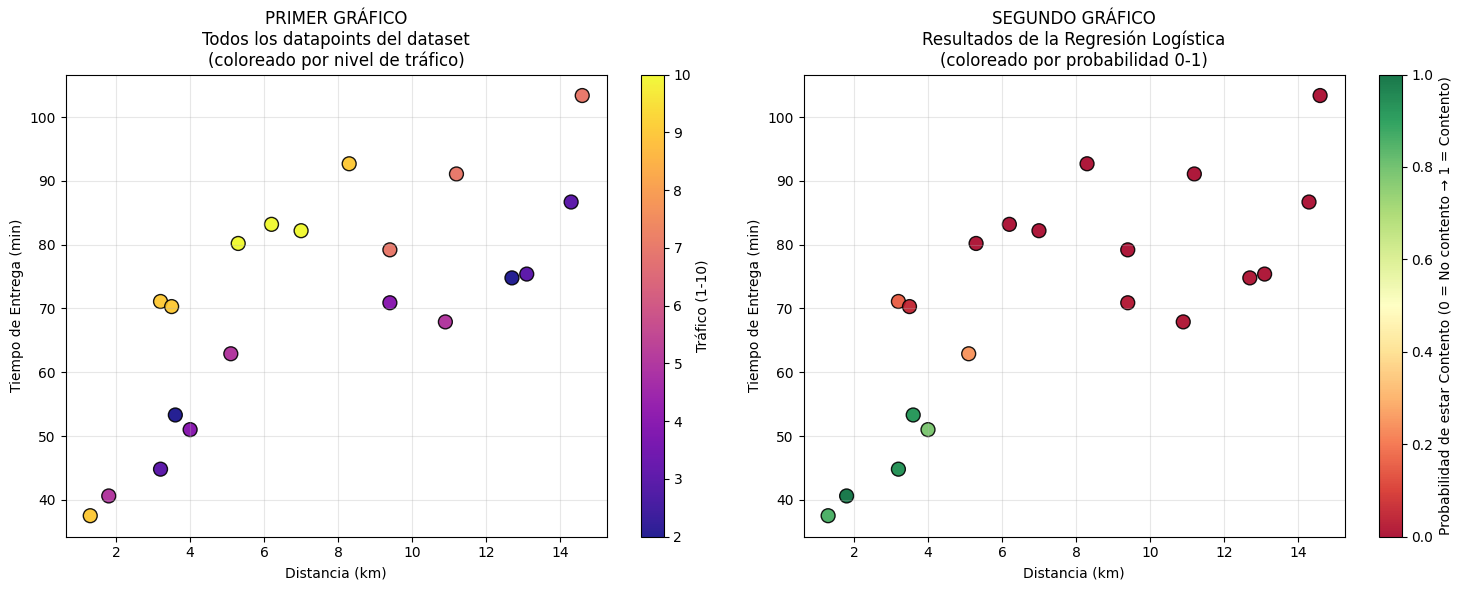


📋 DATASET FINAL con la nueva columna 'Prob_Contento' (valor entre 0 y 1):
     #  Pred_Contento  Prob_Contento
0    1              0       0.002599
1    2              0       0.001703
2    3              0       0.000536
3    4              0       0.018864
4    5              0       0.159682
5    6              1       0.933104
6    7              1       0.988429
7    8              0       0.006643
8    9              0       0.003232
9   10              0       0.011151
10  11              1       0.853141
11  12              0       0.000007
12  13              0       0.009273
13  14              1       0.782708
14  15              0       0.054011
15  16              1       0.921022
16  17              0       0.004064
17  18              0       0.000299
18  19              0       0.001169
19  20              0       0.248194


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ ¡Script terminado! Archivo descargado con la nueva columna.
   • Cambia el umbral de 60 minutos en la definición de la variable 'y' si quieres otro criterio.


In [2]:
# ========================
# SCRIPT PARA GOOGLE COLAB
# Regresión Logística: ¿Está el consumidor contento o no?
# ========================

# PASO 1: Ejecuta esta celda para instalar/importar todo (nada extra necesario en Colab)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from google.colab import files

print("✅ Librerías cargadas correctamente")

# PASO 2: Sube tu archivo Excel
print("Por favor, sube el archivo 'dataset_delivery.xlsx'")
uploaded = files.upload()

# Cargar el dataset (salta la fila del título y toma la cabecera correcta)
df = pd.read_excel('dataset_delivery.xlsx', sheet_name='Dataset', header=1)

# Mostrar vista previa
print("\n📊 Dataset cargado correctamente:")
print(df.head())
print(f"Filas: {len(df)}, Columnas: {df.shape[1]}")

# ========================
# DEFINICIÓN DE LA VARIABLE OBJETIVO PARA LA REGRESIÓN LOGÍSTICA
# ========================
# La variable objetivo binaria (Contento: 1 = feliz, 0 = no contento)
# se define directamente para el modelo a partir de 'Tiempo Entrega (min)'.
# No se crea una nueva columna 'Contento' en el DataFrame 'df' para este propósito.
# Contento = 1 si Tiempo de Entrega <= 60 minutos (entrega rápida)
# Contento = 0 si > 60 minutos
# Puedes cambiar el 60 por cualquier otro valor que prefieras.


# ========================
# REGRESIÓN LOGÍSTICA
# ========================
# Variables predictoras (features)
features = ['Distancia (km)', 'Tráfico (1-10)', 'Hora Pico', 'Pedidos Pendientes']
X = df[features]
y = np.where(df['Tiempo Entrega (min)'] <= 60, 1, 0)

# Entrenamos el modelo (usamos todo el dataset porque es pequeño)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X, y)

# Predicciones y probabilidades (0 a 1)
df['Pred_Contento'] = model.predict(X) #Predicción 0 o 1
df['Prob_Contento'] = model.predict_proba(X)[:, 1]  #Probabilidad de ser 0 o 1

# Precisión del modelo (en entrenamiento)
accuracy = model.score(X, y)


print(f"\n🎯 Precisión del modelo: {accuracy:.2%} (en los 20 registros)")

# ========================
# GRÁFICOS
# ========================
plt.figure(figsize=(15, 6))

# === PRIMER GRÁFICO: Todos los datapoints del dataset ===
plt.subplot(1, 2, 1)
scatter1 = plt.scatter(df['Distancia (km)'],
                      df['Tiempo Entrega (min)'],
                      c=df['Tráfico (1-10)'],
                      cmap='plasma',
                      s=100,
                      edgecolor='black',
                      alpha=0.9)
plt.colorbar(scatter1, label='Tráfico (1-10)')
plt.xlabel('Distancia (km)')
plt.ylabel('Tiempo de Entrega (min)')
plt.title('PRIMER GRÁFICO\nTodos los datapoints del dataset\n(coloreado por nivel de tráfico)')
plt.grid(True, alpha=0.3)

# === SEGUNDO GRÁFICO: Resultados de la Regresión Logística ===
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(df['Distancia (km)'],
                      df['Tiempo Entrega (min)'],
                      c=df['Prob_Contento'],
                      cmap='RdYlGn',
                      s=100,
                      edgecolor='black',
                      vmin=0,
                      vmax=1,
                      alpha=0.9)
plt.colorbar(scatter2, label='Probabilidad de estar Contento (0 = No contento → 1 = Contento)')
plt.xlabel('Distancia (km)')
plt.ylabel('Tiempo de Entrega (min)')
plt.title('SEGUNDO GRÁFICO\nResultados de la Regresión Logística\n(coloreado por probabilidad 0-1)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ========================
# DATASET ACTUALIZADO CON LA NUEVA COLUMNA 0-1
# ========================
print("\n📋 DATASET FINAL con la nueva columna 'Prob_Contento' (valor entre 0 y 1):")
print(df[['#', 'Pred_Contento', 'Prob_Contento']])

# Guardar y descargar el archivo actualizado
df.to_excel('dataset_delivery_con_probabilidad.xlsx', index=False)
files.download('dataset_delivery_con_probabilidad.xlsx')

print("\n✅ ¡Script terminado! Archivo descargado con la nueva columna.")
print("   • Cambia el umbral de 60 minutos en la definición de la variable 'y' si quieres otro criterio.")

## Resumen del Manual Completo

Este manual detallado ha sido diseñado para guiarte a través de un script de Google Colab que implementa un modelo de Regresión Logística. Su objetivo principal es **predecir la satisfacción del cliente en servicios de entrega** (contento/no contento) basándose en factores clave como la distancia, el tráfico, la hora pico y los pedidos pendientes.

### Hallazgos Clave y Características del Script:

*   **Propósito Didáctico**: El script está estructurado con un **enfoque didáctico** para facilitar la comprensión de los conceptos fundamentales de la Regresión Logística y el Machine Learning, incluso para usuarios principiantes.

*   **Librerías Esenciales**: Se utilizan librerías estándar de Python como **`pandas`** para la manipulación de datos, **`numpy`** para operaciones numéricas, **`matplotlib.pyplot`** para la visualización, **`sklearn.linear_model.LogisticRegression`** para el modelado y **`google.colab.files`** para la interacción con archivos en Google Colab.

*   **Carga de Datos Interactiva**: El proceso inicia con la **carga interactiva** del archivo `dataset_delivery.xlsx`, leyendo la hoja 'Dataset' y ajustando la cabecera para una correcta interpretación de los datos.

*   **Definición Flexible de la Variable Objetivo**: La variable objetivo binaria `y` (1 = contento, 0 = no contento) se define **internamente** a partir del `Tiempo Entrega (min)`. El umbral predeterminado es de **60 minutos**, pero se destaca la facilidad para **ajustar este criterio** directamente en el código (`y = np.where(df['Tiempo Entrega (min)'] <= 60, 1, 0)`), lo que permite al usuario experimentar con diferentes definiciones de satisfacción sin modificar la estructura del DataFrame original.

*   **Variables Predictoras**: El modelo utiliza `Distancia (km)`, `Tráfico (1-10)`, `Hora Pico` y `Pedidos Pendientes` como variables de entrada para realizar las predicciones.

*   **Entrenamiento del Modelo**: Un modelo de `LogisticRegression` es entrenado con `max_iter=1000` para asegurar la convergencia y `random_state=42` para garantizar la **reproducibilidad** de los resultados.

*   **Generación de Predicciones**: El script añade al DataFrame dos columnas cruciales: `Pred_Contento` (la predicción binaria del modelo, 0 o 1) y `Prob_Contento` (la probabilidad calculada por el modelo de que el cliente esté contento, un valor entre 0 y 1).

*   **Precisión del Modelo**: En este ejemplo didáctico, el modelo alcanzó una **precisión del 100%** en el conjunto de entrenamiento. Se enfatiza que, si bien esto demuestra la capacidad del modelo para aprender los patrones en un dataset pequeño y separable, en escenarios reales se recomendaría el uso de divisiones de entrenamiento/prueba para evaluar la generalización y evitar el sobreajuste.

*   **Visualizaciones Clarificadoras**: Se generan dos gráficos de dispersión:
    *   El **Primer Gráfico** muestra la relación entre `Distancia (km)` y `Tiempo Entrega (min)`, coloreado por el nivel de `Tráfico (1-10)`, para entender los patrones iniciales de los datos.
    *   El **Segundo Gráfico** utiliza los mismos ejes, pero colorea los puntos por la `Prob_Contento` (mapa de color Rojo-Amarillo-Verde), permitiendo una **interpretación visual directa** de las decisiones del modelo y las probabilidades de satisfacción.

*   **Exportación del Dataset Enriquecido**: El DataFrame final, que incluye las columnas `Pred_Contento` y `Prob_Contento`, es automáticamente guardado como `dataset_delivery_con_probabilidad.xlsx` y **descargado a tu máquina local**, facilitando el análisis posterior en otras herramientas.

### Guía de Uso Rápida y Amigable:

El manual también proporciona una **guía concisa y numerada** sobre cómo ejecutar el script en Google Colab, interactuar con las celdas, modificar el umbral de 'Contento' y comprender la descarga automática del archivo final. Este enfoque paso a paso asegura una experiencia de usuario fluida y efectiva.

En resumen, este manual es una **herramienta completa y didáctica** para cualquier persona interesada en comprender y aplicar la Regresión Logística en un contexto práctico, maximizando la interactividad y la claridad en Google Colab.